# 03 — Ablation: Residual Compression `nbits` ∈ {1, 2, 4}

Runs the full SciFact corpus through the nbits sweep and visualises the
index-size vs. quality trade-off.

**Prerequisites:** Notebook 01 must have run (`results/metrics/bm25.json`).

**Runtime:** ~30–60 min on GPU; 3–9 h on CPU. Plan accordingly.

In [1]:
import os, sys

# ── Auto-detect environment ───────────────────────────────────────────────────
try:
    import google.colab; _IN_COLAB = True
except ImportError:
    _IN_COLAB = False

_IN_KAGGLE = os.path.exists("/kaggle/working")

if _IN_COLAB or _IN_KAGGLE:
    # Remote: repo will be cloned in the next cell — update REPO_URL first.
    REPO_URL  = "https://github.com/YOUR_ORG/cs410-tech-review.git"  # ← REPLACE
    REPO_ROOT = "/content/cs410-tech-review" if _IN_COLAB else "/kaggle/working/cs410-tech-review"
else:
    # Local: locate the repo root relative to this notebook.
    _here = os.path.abspath(".")
    if os.path.basename(_here) == "notebooks" and os.path.isdir(os.path.join(_here, "..", "src")):
        REPO_ROOT = os.path.abspath(os.path.join(_here, ".."))
    elif os.path.isdir(os.path.join(_here, "src")):
        REPO_ROOT = _here
    else:
        REPO_ROOT = _here  # fallback: set manually if this prints the wrong path
    REPO_URL = None
    print(f"Local mode — REPO_ROOT: {REPO_ROOT}")

Local mode — REPO_ROOT: /home/kaiyul3/cs410-tech-review


In [2]:
# Clone repo (Colab / Kaggle only — skipped automatically in local mode).
if REPO_URL and not os.path.isdir(REPO_ROOT):
    !git clone {REPO_URL} {REPO_ROOT}
elif REPO_URL:
    print(f"Repo already present at {REPO_ROOT}")
else:
    print("Local mode — skipping clone.")

Local mode — skipping clone.


In [3]:
if _IN_COLAB or _IN_KAGGLE:
    %pip install -q \
        "torch>=2.1.0,<2.4.0" \
        "transformers==4.44.2" \
        "tokenizers<0.20" \
        "faiss-cpu>=1.7.4" \
        "ragatouille==0.0.9.post2" \
        "colbert-ai>=0.2.19" \
        "langchain==0.1.20" \
        "langchain-core==0.1.53" \
        "rank_bm25>=0.2.2" \
        "beir>=2.0.0" \
        "ranx>=0.3.16" \
        "scipy>=1.11.0" \
        "numpy>=1.24.0,<2.0.0" \
        "pandas>=2.0.0" \
        "pydantic>=2.0.0" \
        "matplotlib>=3.7.0" \
        "seaborn>=0.12.0" \
        "tqdm>=4.65.0" \
        "pyyaml>=6.0" \
        "ninja"
    print("Dependencies installed.")
else:
    # Local: colbert-review conda env already provides everything.
    # Inject the env's bin dir at the head of PATH so subprocesses the kernel
    # spawns (notably ColBERT's JIT C++ extension build via ninja) resolve the
    # right ninja/g++/nvcc, regardless of how the kernel was launched.
    import sys
    _env_bin = os.path.dirname(sys.executable)
    _path = os.environ.get("PATH", "")
    if _env_bin not in _path.split(os.pathsep):
        os.environ["PATH"] = _env_bin + os.pathsep + _path
    print(f"Local mode — using existing env at {_env_bin}")

Local mode — using existing env at /home/kaiyul3/.conda/envs/colbert-review/bin


In [4]:
import sys, os, json
from pathlib import Path

if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

RUNS_DIR    = Path(REPO_ROOT) / "results" / "runs"
METRICS_DIR = Path(REPO_ROOT) / "results" / "metrics"
FIGURES_DIR = Path(REPO_ROOT) / "results" / "figures"
DATA_DIR    = Path(REPO_ROOT) / "data" / "raw"
INDEX_ROOT  = Path(REPO_ROOT) / ".ragatouille"

for d in [RUNS_DIR, METRICS_DIR, FIGURES_DIR, DATA_DIR, INDEX_ROOT]:
    os.makedirs(d, exist_ok=True)
print("Paths ready.")

Paths ready.


In [5]:
import torch
if torch.cuda.is_available():
    device = "cuda"
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    device = "cpu"
    print("WARNING: No GPU. ColBERT indexing will be very slow.")

GPU: NVIDIA A100-SXM4-80GB


## 1. Load full SciFact corpus

In [6]:
from src.data.load_scifact import load_scifact

corpus = load_scifact(split="test", raw_dir=str(DATA_DIR))
print(f"Corpus: {len(corpus.docs):,} docs | "
      f"{len(corpus.queries):,} queries | "
      f"{len(corpus.qrels):,} qrels")

/home/kaiyul3/.conda/envs/colbert-review/lib/python3.10/site-packages/beir/util.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
03:53:48 INFO  src.data.load_scifact — Loading scifact split=test from /home/kaiyul3/cs410-tech-review/data/raw/scifact
03:53:48 INFO  beir.datasets.data_loader — Loading Corpus...


  0%|          | 0/5183 [00:00<?, ?it/s]

03:53:48 INFO  beir.datasets.data_loader — Loaded 5183 TEST Documents.
03:53:48 INFO  beir.datasets.data_loader — Doc Example: {'text': 'Alterations of the architecture of cerebral white matter in the developing human brain can affect cortical development and result in functional disabilities. A line scan diffusion-weighted magnetic resonance imaging (MRI) sequence with diffusion tensor analysis was applied to measure the apparent diffusion coefficient, to calculate relative anisotropy, and to delineate three-dimensional fiber architecture in cerebral white matter in preterm (n = 17) and full-term infants (n = 7). To assess effects of prematurity on cerebral white matter development, early gestation preterm infants (n = 10) were studied a second time at term. In the central white matter the mean apparent diffusion coefficient at 28 wk was high, 1.8 microm2/ms, and decreased toward term to 1.2 microm2/ms. In the posterior limb of the internal capsule, the mean apparent diffusion coeffic

Corpus: 5,183 docs | 300 queries | 339 qrels


## 2. Run nbits sweep

`run_sweep` builds one index per nbits value, runs all queries, evaluates,
and writes per-variant TREC files, JSON metric files, and a summary CSV.

In [7]:
from src.ablation.nbits_sweep import run_sweep

print("Starting nbits sweep...")
records = run_sweep(
    corpus=corpus,
    nbits_values=(1, 2, 4),
    topk=100,
    checkpoint="colbert-ir/colbertv2.0",
    index_name_prefix="scifact",
    runs_dir=str(RUNS_DIR),
    metrics_dir=str(METRICS_DIR),
    max_document_length=256,
)

print(f"\nSweep complete — {len(records)} variants:")
for r in records:
    print(f"  nbits={r.nbits}: {r.index_mib:.1f} MiB | "
          f"ndcg@10={r.metrics.get('ndcg@10', float('nan')):.4f} | "
          f"p50={r.latency_p50_ms:.1f}ms")

03:53:48 INFO  src.ablation.nbits_sweep — === Ablation variant: nbits1 ===
/home/kaiyul3/cs410-tech-review/src/colbert/index.py:58: UserWarning: 
********************************************************************************
RAGatouille WARNING: Future Release Notice
--------------------------------------------
RAGatouille version 0.0.10 will be migrating to a PyLate backend 
instead of the current Stanford ColBERT backend.
PyLate is a fully mature, feature-equivalent backend, that greatly facilitates compatibility.
However, please pin version <0.0.10 if you require the Stanford ColBERT backend.
********************************************************************************
  from ragatouille import RAGPretrainedModel  # lazy import


Starting nbits sweep...


03:53:54 INFO  faiss.loader — Loading faiss with AVX2 support.
03:53:54 INFO  faiss.loader — Successfully loaded faiss with AVX2 support.
03:53:56 INFO  src.colbert.index — Loading ColBERT checkpoint: colbert-ir/colbertv2.0
/home/kaiyul3/.conda/envs/colbert-review/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
03:53:57 INFO  src.colbert.index — Building ColBERT index 'scifact_nbits1' (nbits=1, n_docs=5183, max_doc_len=256)


---- WARNING! You are using PLAID with an experimental replacement for FAISS for greater compatibility ----
This is a behaviour change from RAGatouille 0.8.0 onwards.
This works fine for most users and smallish datasets, but can be considerably slower than FAISS and could cause worse results in some situations.
If you're confident with FAISS working on your machine, pass use_faiss=True to revert to the FAISS-using behaviour.
--------------------


[May 01, 03:53:57] #> Creating directory .ragatouille/colbert/indexes/scifact_nbits1 


[May 01, 03:53:58] [0] 		 #> Encoding 5183 passages..
[May 01, 03:54:12] [0] 		 avg_doclen_est = 211.18946838378906 	 len(local_sample) = 5,183
[May 01, 03:54:13] [0] 		 Creating 16,384 partitions.
[May 01, 03:54:13] [0] 		 *Estimated* 1,094,595 embeddings.
[May 01, 03:54:13] [0] 		 #> Saving the indexing plan to .ragatouille/colbert/indexes/scifact_nbits1/plan.json ..
used 20 iterations (1.1107s) to cluster 1044595 items into 16384 clusters
[May 01, 03:54

/home/kaiyul3/.conda/envs/colbert-review/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


...

[May 01, 04:15:20] #> Loading codes and residuals...



100%|██████████| 1/1 [00:00<00:00,  2.53it/s]


Searcher loaded!

#> QueryTokenizer.tensorize(batch_text[0], batch_background[0], bsize) ==
#> Input: 0-dimensional biomaterials show inductive properties., 		 True, 		 None
#> Output IDs: torch.Size([32]), tensor([  101,     1,  1014,  1011,  8789, 16012,  8585, 14482,  2015,  2265,
        27427, 14194,  6024,  5144,  1012,   102,   103,   103,   103,   103,
          103,   103,   103,   103,   103,   103,   103,   103,   103,   103,
          103,   103], device='cuda:0')
#> Output Mask: torch.Size([32]), tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')



04:17:02 INFO  src.colbert.search — ColBERT search: 300 queries, total=102.8s, p50=301.0ms, p95=596.5ms
04:17:02 INFO  src.eval.metrics — Wrote 30000 lines to /home/kaiyul3/cs410-tech-review/results/runs/colbert_nbits4.trec
04:17:02 INFO  src.eval.metrics — Saved metrics to /home/kaiyul3/cs410-tech-review/results/metrics/colbert_nbits4.json
04:17:02 INFO  src.ablation.nbits_sweep — Wrote ablation CSV: /home/kaiyul3/cs410-tech-review/results/metrics/ablation_nbits.csv
04:17:02 INFO  src.ablation.nbits_sweep — Wrote ablation JSON: /home/kaiyul3/cs410-tech-review/results/metrics/ablation_nbits.json



Sweep complete — 2 variants:
  nbits=2: 85.0 MiB | ndcg@10=0.6898 | p50=407.6ms
  nbits=4: 85.0 MiB | ndcg@10=0.6898 | p50=301.0ms


## 3. Load results into a DataFrame

In [8]:
import pandas as pd

with open(METRICS_DIR / "ablation_nbits.json") as f:
    raw = json.load(f)  # list of AblationRecord dicts

# Flatten nested "metrics" sub-dict into top-level columns.
rows = []
for r in raw:
    row = {k: v for k, v in r.items() if k != "metrics"}
    row.update(r.get("metrics", {}))
    rows.append(row)
df = pd.DataFrame(rows)

display(df[["nbits","n_docs","build_time_s","index_mib",
            "latency_p50_ms","latency_p95_ms",
            "ndcg@10","mrr@10","map","recall@100"]].to_string(index=False))

' nbits  n_docs  build_time_s  index_mib  latency_p50_ms  latency_p95_ms  ndcg@10  mrr@10      map  recall@100\n     2    5183     18.580811  84.950274      407.600862      700.451776 0.689777 0.66461 0.657725       0.916\n     4    5183     19.750794  84.950274      301.000899      596.478631 0.689777 0.66461 0.657725       0.916'

## 4. Load BM25 reference metrics

In [9]:
bm25_json = METRICS_DIR / "bm25.json"
bm25_metrics = {}
if not bm25_json.exists():
    print(f"WARNING: {bm25_json} not found — run notebook 01 first.")
else:
    with open(bm25_json) as f:
        bm25_metrics = json.load(f).get("metrics", {})
    print("BM25 metrics:")
    for k, v in sorted(bm25_metrics.items()):
        print(f"  {k}: {v:.4f}")

BM25 metrics:
  map: 0.6251
  mrr@10: 0.6317
  ndcg@10: 0.6641
  recall@100: 0.8759


## 5. Index size vs. NDCG@10

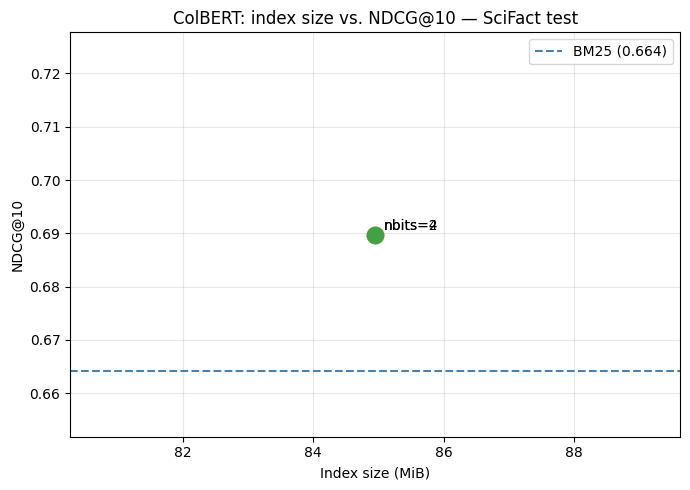

In [10]:
import matplotlib.pyplot as plt

NB_COLORS = {1: "#E8505B", 2: "#F9A825", 4: "#43A047"}

fig, ax = plt.subplots(figsize=(7, 5))
for _, row in df.iterrows():
    nb = int(row["nbits"])
    ax.scatter(row["index_mib"], row["ndcg@10"],
               s=140, color=NB_COLORS.get(nb, "grey"), zorder=3)
    ax.annotate(f"nbits={nb}",
                xy=(row["index_mib"], row["ndcg@10"]),
                xytext=(6, 3), textcoords="offset points", fontsize=10)

if "ndcg@10" in bm25_metrics:
    ax.axhline(bm25_metrics["ndcg@10"], color="steelblue", linestyle="--",
               linewidth=1.5, label=f"BM25 ({bm25_metrics['ndcg@10']:.3f})")

ax.set_xlabel("Index size (MiB)")
ax.set_ylabel("NDCG@10")
ax.set_title("ColBERT: index size vs. NDCG@10 — SciFact test")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "ablation_size_vs_ndcg.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Multi-metric bar chart

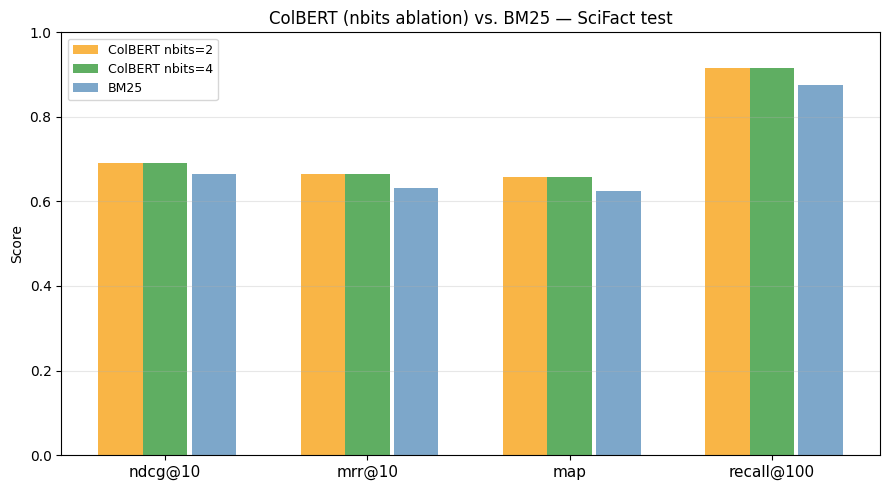

In [11]:
import numpy as np

MPLOT = ["ndcg@10", "mrr@10", "map", "recall@100"]
x, width = np.arange(len(MPLOT)), 0.22

fig, ax = plt.subplots(figsize=(9, 5))
for i, (_, row) in enumerate(df.sort_values("nbits").iterrows()):
    nb   = int(row["nbits"])
    vals = [row.get(m, float("nan")) for m in MPLOT]
    ax.bar(x + (i - 1) * width, vals, width,
           label=f"ColBERT nbits={nb}", color=NB_COLORS.get(nb, "grey"), alpha=0.85)

if bm25_metrics:
    bm25_vals = [bm25_metrics.get(m, float("nan")) for m in MPLOT]
    ax.bar(x + 1 * width + 0.02, bm25_vals, width,
           label="BM25", color="steelblue", alpha=0.70)

ax.set_xticks(x)
ax.set_xticklabels(MPLOT, fontsize=11)
ax.set_ylabel("Score")
ax.set_title("ColBERT (nbits ablation) vs. BM25 — SciFact test")
ax.legend(fontsize=9)
ax.set_ylim(0, 1.0)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "ablation_metrics_bar.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Query latency vs. nbits

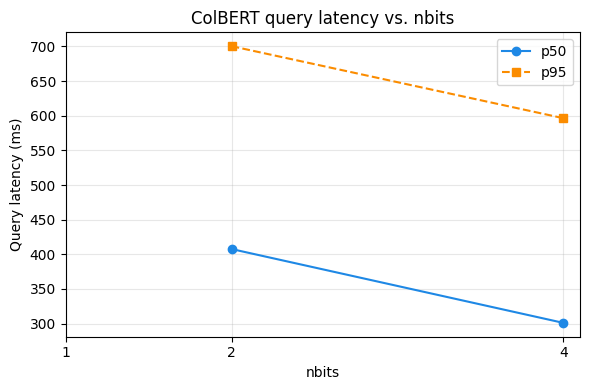

In [12]:
df_s = df.sort_values("nbits")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(df_s["nbits"], df_s["latency_p50_ms"], marker="o", label="p50", color="#1E88E5")
ax.plot(df_s["nbits"], df_s["latency_p95_ms"], marker="s", linestyle="--",
        label="p95", color="#FB8C00")
ax.set_xticks([1, 2, 4])
ax.set_xlabel("nbits")
ax.set_ylabel("Query latency (ms)")
ax.set_title("ColBERT query latency vs. nbits")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "ablation_latency.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Summary table

In [13]:
SCOLS = ["nbits","index_mib","build_time_s",
         "latency_p50_ms","latency_p95_ms",
         "ndcg@10","mrr@10","map","recall@100"]

display(df[SCOLS].sort_values("nbits")
        .style.format({c: "{:.3f}" for c in SCOLS if c != "nbits"})
        .set_caption("ColBERT nbits ablation — SciFact test"))

,nbits,index_mib,build_time_s,latency_p50_ms,latency_p95_ms,ndcg@10,mrr@10,map,recall@100
0,2,84.950,18.581,407.601,700.452,0.690,0.665,0.658,0.916
1,4,84.950,19.751,301.001,596.479,0.690,0.665,0.658,0.916
